# Backtest 009 — RMA/ATR Channel Breakout

Pine-faithful implementation of the **RMA ATR Channel** directional filter on the VN stock universe.

## Strategy logic

| | Rule |
|---|---|
| **Indicator** | Upper band = `RMA(src, ma_length) + ATR(atr_length) × upper_mult`<br>Lower band = `RMA(src, ma_length) − ATR(atr_length) × lower_mult` |
| **Trend state** | Stateful: flips to `+1` when `close > upper`, flips to `−1` when `close < lower`, holds otherwise |
| **Entry** | Trend just flipped to `+1` (bar confirmed, fill at **next open**) |
| **Exit** | Trend just flipped to `−1` (bar confirmed, fill at **next open**) |
| **Source** | `src = High` (default, matches Pine `ta.rma(high, …)`) |

Long-only. 0.1 % fees + 0.2 % slippage.

**Optimisation:** Multi-objective Optuna — maximise `Total Return (%)` and `Sortino Ratio`
over `ma_length, atr_length, upper_mult, lower_mult`.

## 1. Load Data

In [40]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import talib

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'backend'))
import backend.app
import backend.app.services
import backend.app.services.indicators
sys.modules.setdefault('app', backend.app)
sys.modules.setdefault('app.services', backend.app.services)
sys.modules.setdefault('app.services.indicators', backend.app.services.indicators)
from backend.app.services.indicators.trailing_sl import atr_trailing_nb

plt.style.use('dark_background')
print('imports ok')


{'v1': {'bb_window': 23, 'bb_multiplier': 1.5, 'bb_matype': 2, 'kc_window': 21, 'kc_multiplier': 0.9, 'kc_atr_period': 5, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 1.9, 'max_sl': 0.06}, 'v2': {'bb_window': 22, 'bb_multiplier': 2.0, 'bb_matype': 0, 'kc_window': 16, 'kc_multiplier': 0.8, 'kc_atr_period': 13, 'donichan_window': 11, 'osc_smoothing_period': 8, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 2.2, 'max_sl': 0.07}, 'v3': {'bb_window': 11, 'bb_multiplier': 0.9, 'bb_matype': 0, 'kc_window': 20, 'kc_multiplier': 1.9000000000000001, 'kc_atr_period': 19, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 3, 'atr_period': 5, 'atr_multiplier': 3.5, 'max_sl': 0.14, 'william_vix_period': 18, 'consecutive_neg_threshold': 4}}
imports ok


In [41]:
BENCHMARK = 'VNINDEX'
DATA_START = '2019-01-01'

df_raw = load_stocks()
df_raw = df_raw.loc[DATA_START:]

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

print(f'Shape : {close.shape}  |  {close.index[0].date()} -> {close.index[-1].date()}')
print(f'Symbols: {len(valid_syms)}  |  Benchmark: {BENCHMARK}')
close.tail(3)

Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2501, 985)  |  2016-06-27 → 2026-06-26
Shape : (1867, 197)  |  2019-01-02 -> 2026-06-26
Symbols: 197  |  Benchmark: VNINDEX


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-24,7.40,17.9,22.5,44.1,9.10,11.70,14.60,21.70,5.5,5.81,...,1878.02,56.45,12.20,26.55,2.68,62.0,30.3,18.7,63.1,8.93
2026-06-25,7.43,18.2,22.4,44.0,9.15,11.70,14.45,22.45,5.5,5.89,...,1863.07,56.45,12.25,26.70,2.69,62.2,29.6,18.5,63.2,9.55
2026-06-26,7.37,18.0,22.6,43.7,9.22,11.75,14.35,21.95,5.5,5.88,...,1871.91,56.30,12.15,26.75,2.62,61.8,30.0,18.5,62.6,9.68


In [42]:
IS_FRAC   = 0.6
split_idx = int(len(close) * IS_FRAC)
oos_start = close.index[split_idx]

close_is  = close.iloc[:split_idx];  close_oos  = close.iloc[split_idx:]
high_is   = high.iloc[:split_idx];   high_oos   = high.iloc[split_idx:]
low_is    = low.iloc[:split_idx];    low_oos    = low.iloc[split_idx:]
open_is   = open_.iloc[:split_idx];  open_oos   = open_.iloc[split_idx:]

print(f'IS  {close_is.index[0].date()} -> {close_is.index[-1].date()}  ({len(close_is)} bars)')
print(f'OOS {close_oos.index[0].date()} -> {close_oos.index[-1].date()}  ({len(close_oos)} bars)')

IS  2019-01-02 -> 2023-06-28  (1120 bars)
OOS 2023-06-29 -> 2026-06-26  (747 bars)


## 2. Strategy Helpers (RMA/ATR Channel)

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Indicator helpers — Pine-faithful, fully vectorised across all symbols
# ─────────────────────────────────────────────────────────────────────────────

def wilder_rma_df(src: pd.DataFrame, length: int) -> pd.DataFrame:
    """Wilder's smoothing (RMA) — alpha = 1/length, matches ta.rma() in Pine."""
    return src.ewm(alpha=1.0 / length, adjust=False).mean()


def wilder_atr_df(high: pd.DataFrame, low: pd.DataFrame,
                  close: pd.DataFrame, length: int) -> pd.DataFrame:
    """True Range → Wilder RMA, matches ta.atr() in Pine exactly."""
    prev_close = close.shift(1)
    tr = pd.DataFrame(
        np.maximum(
            np.maximum((high - low).values, (high - prev_close).abs().values),
            (low - prev_close).abs().values,
        ),
        index=close.index, columns=close.columns,
    )
    return tr.ewm(alpha=1.0 / length, adjust=False).mean()


def stateful_trend_df(close: pd.DataFrame,
                      upper: pd.DataFrame,
                      lower: pd.DataFrame) -> pd.DataFrame:
    """
    Vectorised stateful trend mirroring Pine `var int trend = 0`:
      +1 when close > upper, -1 when close < lower, hold otherwise.
    """
    raw = np.where(close.values > upper.values,  1.0,
          np.where(close.values < lower.values, -1.0, np.nan))
    df  = pd.DataFrame(raw, index=close.index, columns=close.columns)
    return df.ffill().fillna(0).astype(int)


def compute_signals(
    close:      pd.DataFrame,
    high:       pd.DataFrame,
    low:        pd.DataFrame,
    ma_length:  int   = 200,
    atr_length: int   = 14,
    upper_mult: float = 3.0,
    lower_mult: float = 3.0,
    use_high_src: bool = True,
) -> tuple:
    """
    Returns entries_df on the signal bar (trend just flipped to +1).
    Fills happen at next open (1-bar shift applied inside run_pf).
    """
    src        = high if use_high_src else close
    ma         = wilder_rma_df(src, ma_length)
    atr        = wilder_atr_df(high, low, close, atr_length)
    upper_line = ma + atr * upper_mult
    lower_line = ma - atr * lower_mult

    trend   = stateful_trend_df(close, upper_line, lower_line)
    entries = ((trend == 1) & (trend.shift(1) != 1)).fillna(False)
    return entries


def compute_exits(
    close: pd.DataFrame,
    high:  pd.DataFrame,
    low:   pd.DataFrame,
    atr_multiplier:    float = 1.9,
    atr_period:        int   = 10,
    low_stop_lookback: int   = 5,
    max_sl:            float = 0.1,
):
    """
    Mirrors backtest_005 compute_exits exactly.

    Returns (exits_df, sl_stop_df):
      exits_df   — close crossed below ATR trailing stop.
      sl_stop_df — per-bar relative stop = (close - swing_low) / close,
                   capped at max_sl; passed as sl_stop= in vbt.
    """
    ATR = vbt.IndicatorFactory.from_talib('ATR')
    atr_raw = ATR.run(high, low, close, timeperiod=atr_period)

    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0, upper=max_sl)

    return exits_df, sl_stop_df


def run_pf(open_px: pd.DataFrame, entries: pd.DataFrame,
           exits: pd.DataFrame, sl_stop: pd.DataFrame,
           fees: float = 0.001, slippage: float = 0.002, init_cash: float = 100.0):
    """Per-symbol portfolios, fills at NEXT open (signals shifted by 1 bar)."""
    entries_s = entries.shift(1).fillna(False)
    exits_s   = exits.shift(1).fillna(False)
    return vbt.Portfolio.from_signals(
        close=open_px, entries=entries_s, exits=exits_s,
        freq='1d', cash_sharing=False,
        fees=fees, slippage=slippage, init_cash=init_cash,
        sl_stop=sl_stop,
    )


print('Strategy helpers defined')


Strategy helpers defined


## 3. Baseline Run (Pine default params)

Default: `ma_length=200, atr_length=14, upper_mult=3.0, lower_mult=3.0, src=High`.

In [44]:
# VNINDEX Buy & Hold — full-sample reference
bm_entries = pd.DataFrame(False, index=close.index, columns=[BENCHMARK]); bm_entries.iloc[0, 0] = True
bm_exits   = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])
pf_bh = vbt.Portfolio.from_signals(
    close=close[[BENCHMARK]], entries=bm_entries, exits=bm_exits,
    freq='1d', cash_sharing=False, init_cash=100,
)
print(f'VNINDEX Buy & Hold (full)  Total Return={float(np.atleast_1d(pf_bh.total_return())[0]):.1%}  '
      f'Sharpe={float(np.atleast_1d(pf_bh.sharpe_ratio())[0]):.3f}')

# Strategy at Pine defaults across the universe (full sample)
DEFAULT_PARAMS = dict(ma_length=200, atr_length=14, upper_mult=3.0, lower_mult=3.0, use_high_src=True)
DEFAULT_EXIT   = dict(atr_multiplier=1.9, atr_period=10, low_stop_lookback=5, max_sl=0.1)

ent_def          = compute_signals(close, high, low, **DEFAULT_PARAMS)
exits_def, sl_def = compute_exits(close, high, low, **DEFAULT_EXIT)
pf_def           = run_pf(open_, ent_def, exits_def, sl_def)

tr = pf_def.total_return().replace([np.inf, -np.inf], np.nan).dropna()
sh = pf_def.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
so = pf_def.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
print(f'\nRMA-ATR default (full, {len(tr)} symbols)')
print(f'  Mean Total Return : {tr.mean():.1%}')
print(f'  Median Total Ret  : {tr.median():.1%}')
print(f'  Mean Sharpe       : {sh.mean():.3f}   |  % symbols Sharpe>0: {(sh>0).mean():.0%}')
print(f'  Mean Sortino      : {so.mean():.3f}')


VNINDEX Buy & Hold (full)  Total Return=109.9%  Sharpe=0.737

RMA-ATR default (full, 197 symbols)
  Mean Total Return : 5.7%
  Median Total Ret  : -0.6%
  Mean Sharpe       : 0.009   |  % symbols Sharpe>0: 55%
  Mean Sortino      : 0.099


## 4. Optuna Robustness Search (IS)

Maximise (`Total Return %`, `Sortino`) over `ma_length, atr_length, upper_mult, lower_mult`
on the in-sample slice. Penalise if fewer than 30 % of symbols are profitable.

In [52]:
def objective(trial):
    ma_length  = trial.suggest_int(  'ma_length',   50,  300)
    atr_length = trial.suggest_int(  'atr_length',   5,   30)
    upper_mult = trial.suggest_float('upper_mult',  1.5,  5.0, step=0.25)
    lower_mult = trial.suggest_float('lower_mult',  1.5,  5.0, step=0.25)
    use_high   = trial.suggest_categorical('use_high_src', [True, False])
    # exit params (mirrors backtest_005 search space)
    low_stop_lookback = trial.suggest_int(  'low_stop_lookback', 2,    5)
    atr_period        = trial.suggest_int(  'atr_period',        5,   20)
    atr_multiplier    = trial.suggest_float('atr_multiplier',    1.5,  3.0, step=0.1)
    max_sl            = trial.suggest_float('max_sl',            0.04, 0.15, step=0.01)
    try:
        ent = compute_signals(
            close_is, high_is, low_is,
            ma_length=ma_length, atr_length=atr_length,
            upper_mult=upper_mult, lower_mult=lower_mult,
            use_high_src=use_high,
        )
        ex, sl = compute_exits(
            close_is, high_is, low_is,
            atr_multiplier=atr_multiplier, atr_period=atr_period,
            low_stop_lookback=low_stop_lookback, max_sl=max_sl,
        )
        pf        = run_pf(open_is, ent, ex, sl)
        total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
        sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        if len(total_ret) == 0:
            return -999.0, -999.0
        mean_ret  = float(total_ret.mean() * 100)
        mean_sort = float(sortino.mean()) if len(sortino) else -999.0
        if len(sharpe) and (sharpe > 0).mean() < 0.3:
            mean_ret  *= 0.5
            mean_sort *= 0.5
        return mean_ret, mean_sort
    except Exception:
        return -999.0, -999.0


N_TRIALS = 500
study = optuna.create_study(
    directions=['maximize', 'maximize'],
    study_name='rma_atr_channel',
    sampler=optuna.samplers.NSGAIISampler(seed=42),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'\nPareto front: {len(study.best_trials)} trials')


  0%|          | 0/500 [00:00<?, ?it/s]


Pareto front: 1 trials


## 5. Select Best Params

In [53]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick(study, mode='balanced'):
    front = study.best_trials
    if mode == 'best_return':
        t = max(front, key=lambda t: t.values[0])
    elif mode == 'best_sortino':
        t = max(front, key=lambda t: t.values[1])
    else:  # balanced: rank-normalise both objectives, maximise sum
        rets  = [t.values[0] for t in front]
        sorts = [t.values[1] for t in front]
        def nrm(v, arr):
            lo, hi = min(arr), max(arr)
            return 0.0 if hi == lo else (v - lo) / (hi - lo)
        t = max(front, key=lambda t: nrm(t.values[0], rets) + nrm(t.values[1], sorts))
    return t

best_trial  = pick(study, SELECTION)
best_params = best_trial.params
print('Selection :', SELECTION)
print('Best params:', best_params)
print(f'IS objectives  Total Return={best_trial.values[0]:.1f}%   Sortino={best_trial.values[1]:.3f}')

Selection : balanced
Best params: {'ma_length': 56, 'atr_length': 13, 'upper_mult': 1.5, 'lower_mult': 1.75, 'use_high_src': True, 'low_stop_lookback': 5, 'atr_period': 9, 'atr_multiplier': 2.8, 'max_sl': 0.11000000000000001}
IS objectives  Total Return=29.3%   Sortino=0.384


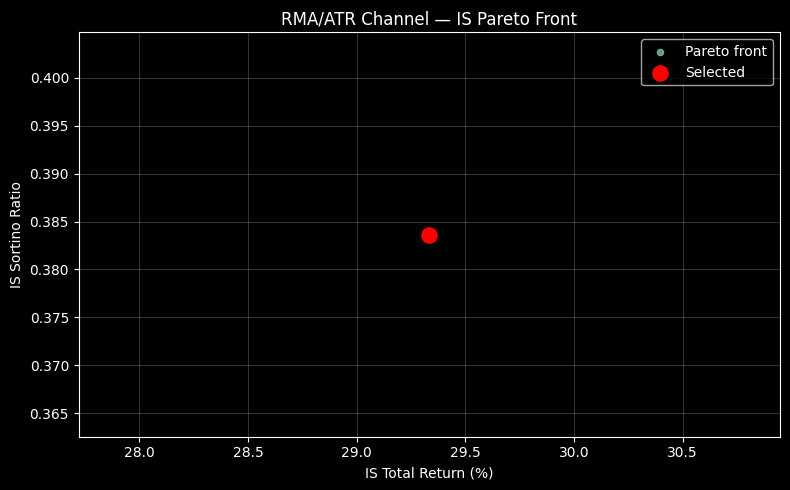

In [54]:
# Pareto front scatter
front = study.best_trials
xs = [t.values[0] for t in front]
ys = [t.values[1] for t in front]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(xs, ys, s=20, alpha=0.7, label='Pareto front')
ax.scatter([best_trial.values[0]], [best_trial.values[1]], s=120, color='red', zorder=5, label='Selected')
ax.set_xlabel('IS Total Return (%)')
ax.set_ylabel('IS Sortino Ratio')
ax.set_title('RMA/ATR Channel — IS Pareto Front')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## 6. OOS Evaluation — default vs optimised vs VNINDEX

In [55]:
# VNINDEX Buy & Hold on OOS
bm_e = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK]); bm_e.iloc[0, 0] = True
bm_x = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])
pf_base = vbt.Portfolio.from_signals(
    close=close_oos[[BENCHMARK]], entries=bm_e, exits=bm_x,
    freq='1d', cash_sharing=False, init_cash=100,
)
bh_ret_oos = float(np.atleast_1d(pf_base.total_return())[0])
bh_shp_oos = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
print(f'VNINDEX Buy & Hold (OOS)  Total Return={bh_ret_oos:.1%}  Sharpe={bh_shp_oos:.3f}')


def oos_pf(entry_params, exit_params):
    ent     = compute_signals(close_oos, high_oos, low_oos, **entry_params)
    ex, sl  = compute_exits(close_oos, high_oos, low_oos, **exit_params)
    return run_pf(open_oos, ent, ex, sl)


# Split best_params into entry / exit groups
EXIT_KEYS = {'low_stop_lookback', 'atr_period', 'atr_multiplier', 'max_sl'}
ENTRY_KEYS = set(best_params) - EXIT_KEYS
best_entry = {k: best_params[k] for k in ENTRY_KEYS}
best_exit  = {k: best_params[k] for k in EXIT_KEYS}

portfolios = {
    'default':   oos_pf(DEFAULT_PARAMS, DEFAULT_EXIT),
    'optimised': oos_pf(best_entry, best_exit),
}
for name, pf in portfolios.items():
    print(f'  {name:9s}  mean Sharpe={pf.sharpe_ratio().mean():.3f}  '
          f'mean Total Ret={pf.total_return().mean():.1%}  '
          f'(Delta Sharpe vs VNINDEX {pf.sharpe_ratio().mean()-bh_shp_oos:+.3f})')


VNINDEX Buy & Hold (OOS)  Total Return=66.3%  Sharpe=1.230
  default    mean Sharpe=inf  mean Total Ret=-1.7%  (Delta Sharpe vs VNINDEX +inf)
  optimised  mean Sharpe=-0.028  mean Total Ret=1.2%  (Delta Sharpe vs VNINDEX -1.257)


## 7. Comparison — Stats Table

In [56]:
def version_stats(name, pf):
    tr  = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
    sh  = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so  = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    mdd = pf.max_drawdown().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'mean_total_return_%':    round(tr.mean() * 100, 2),
        'median_total_return_%':  round(tr.median() * 100, 2),
        'mean_sharpe':            round(sh.mean(), 3),
        'pct_sharpe_pos':         round((sh > 0).mean() * 100, 1),
        'mean_sortino':           round(so.mean(), 3),
        'mean_max_dd_%':          round(mdd.mean() * 100, 2),
        'n_symbols':              int(len(tr)),
    }

stats_df = pd.DataFrame({name: version_stats(name, pf) for name, pf in portfolios.items()}).T
stats_df.loc['VNINDEX_BH'] = {
    'mean_total_return_%':   round(bh_ret_oos * 100, 2),
    'median_total_return_%': round(bh_ret_oos * 100, 2),
    'mean_sharpe':           round(bh_shp_oos, 3),
    'pct_sharpe_pos': np.nan, 'mean_sortino': np.nan, 'mean_max_dd_%': np.nan, 'n_symbols': 1,
}
stats_df

,mean_total_return_%,median_total_return_%,mean_sharpe,pct_sharpe_pos,mean_sortino,mean_max_dd_%,n_symbols
default,-1.75,-5.06,-0.221,35.2,-0.154,-13.58,197.0
optimised,1.18,-5.54,-0.028,50.8,0.030,-25.54,197.0
VNINDEX_BH,66.33,66.33,1.230,NaN,NaN,NaN,1.0


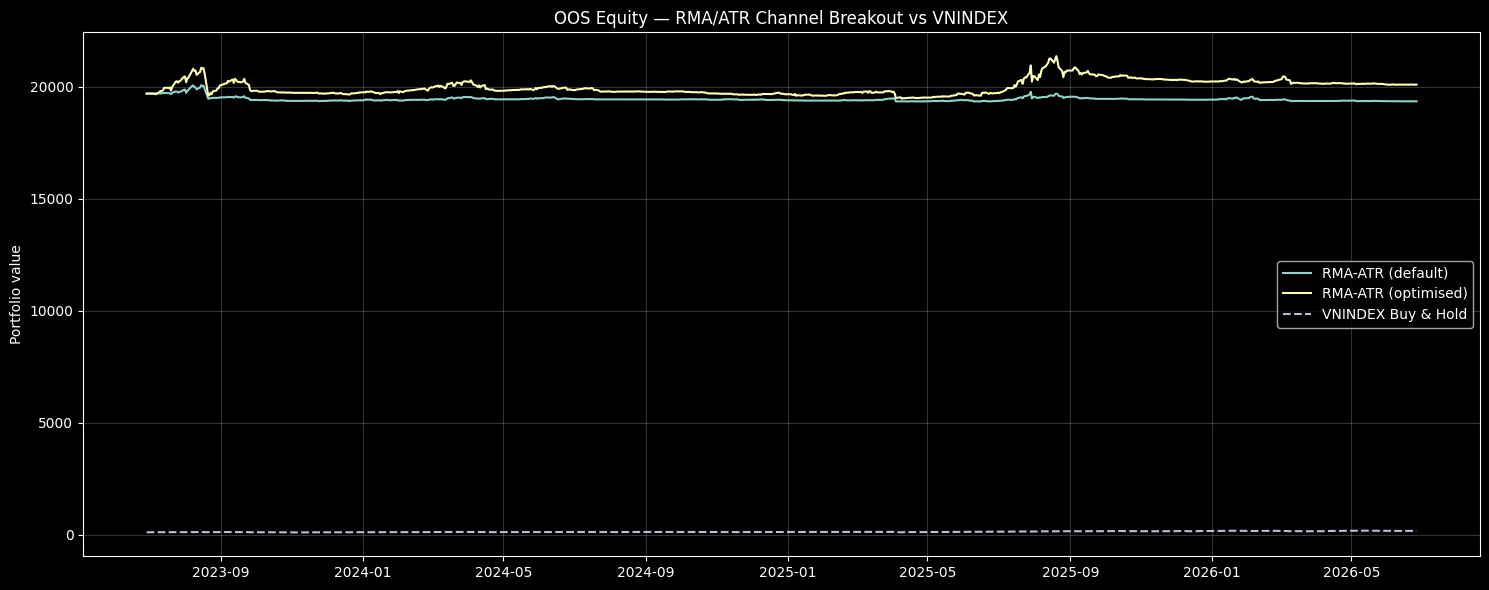

In [50]:
# Equity curves — OOS
fig, ax = plt.subplots(figsize=(15, 6))
for name, pf in portfolios.items():
    ax.plot(pf.value().sum(axis=1), label=f'RMA-ATR ({name})', linewidth=1.5)
ax.plot(pf_base.value(), label='VNINDEX Buy & Hold', linewidth=1.5, linestyle='--')
ax.set_title('OOS Equity — RMA/ATR Channel Breakout vs VNINDEX')
ax.set_ylabel('Portfolio value'); ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

In [ ]:
# Distribution of per-symbol Total Return and Sharpe Ratio (OOS)
COLORS = {'default': '#3498db', 'optimised': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics = [
    ('Total Return (%)', lambda pf: pf.total_return().replace([np.inf, -np.inf], np.nan).dropna() * 100),
    ('Sharpe Ratio',     lambda pf: pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()),
]
bm_vals = [
    bh_ret_oos * 100,
    bh_shp_oos,
]

for ax, (title, extractor), bm_val in zip(axes, metrics, bm_vals):
    for name, pf in portfolios.items():
        vals = extractor(pf)
        ax.hist(vals, bins=40, alpha=0.45, color=COLORS[name], label=f'{name} (n={len(vals)})')
        ax.axvline(vals.mean(), color=COLORS[name], linewidth=1.8, linestyle='--',
                   label=f'{name} mean={vals.mean():.2f}')
    ax.axvline(bm_val, color='orange', linewidth=2, linestyle='-',
               label=f'VNINDEX BH = {bm_val:.2f}')
    ax.set_title(f'OOS {title} distribution')
    ax.set_xlabel(title)
    ax.set_ylabel('Symbol count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Per-symbol OOS distribution — all portfolio variants', y=1.02)
plt.tight_layout()
plt.show()


In [51]:
# Signal visualisation — single symbol (VNINDEX or first valid symbol)
INSPECT_SYM = BENCHMARK if BENCHMARK in close_oos.columns else close_oos.columns[0]
ent_opt, ex_opt = compute_signals(close_oos, high_oos, low_oos, **best_params)

src_oos   = high_oos if best_params.get('use_high_src', True) else close_oos
ma_v      = wilder_rma_df(src_oos[[INSPECT_SYM]], best_params['ma_length'])
atr_v     = wilder_atr_df(high_oos[[INSPECT_SYM]], low_oos[[INSPECT_SYM]], close_oos[[INSPECT_SYM]], best_params['atr_length'])
upper_v   = ma_v + atr_v * best_params['upper_mult']
lower_v   = ma_v - atr_v * best_params['lower_mult']

fig, ax = plt.subplots(figsize=(16, 6))
c = close_oos[INSPECT_SYM]
ax.plot(c, label='Close', lw=1, color='white', alpha=0.8)
ax.plot(ma_v[INSPECT_SYM], label='RMA', lw=1.2, color='cyan')
ax.plot(upper_v[INSPECT_SYM], label='Upper band', lw=0.8, color='lime', linestyle='--')
ax.plot(lower_v[INSPECT_SYM], label='Lower band', lw=0.8, color='tomato', linestyle='--')
ax.fill_between(c.index, upper_v[INSPECT_SYM], lower_v[INSPECT_SYM], alpha=0.05, color='yellow')

# Entry / exit markers
e_idx = c.index[ent_opt[INSPECT_SYM].values]
x_idx = c.index[ex_opt[INSPECT_SYM].values]
ax.scatter(e_idx, c.loc[e_idx], marker='^', color='lime', s=60, zorder=5, label='Entry')
ax.scatter(x_idx, c.loc[x_idx], marker='v', color='tomato', s=60, zorder=5, label='Exit')

ax.set_title(f'RMA/ATR Channel — {INSPECT_SYM} (OOS, optimised params)')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

TypeError: compute_signals() got an unexpected keyword argument 'low_stop_lookback'

## 8. Save Results to HDF5

In [ ]:
out_path = pathlib.Path('backtest_009_results.h5')
with pd.HDFStore(out_path, mode='w') as store:
    store.put('stats', stats_df)
    store.put('best_params', pd.Series(best_params))
    for name, pf in portfolios.items():
        store.put(f'oos_total_return/{name}', pf.total_return().rename(name))
print(f'Saved -> {out_path.resolve()}')

Saved -> /Users/phuchuynh/Work/all-in-one-portfolio/notebooks/backtest_009_results.h5
